In [ ]:
pip install torch_geometric torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.6.0+cpu.html

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cpu.html


In [ ]:
pip install torch-scatter -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html


In [ ]:
pip install torch-sparse -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html


In [ ]:
pip install torch-cluster -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html


In [ ]:
pip install torch-geometric

In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
# Step 2: Import libraries
import os
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances
import torch
import os
import pandas as pd
import numpy as np

base_path = '/content/drive/MyDrive/Projects'

folders = ['Alzheimers_PLV_CSV_theta_only', 'Fronto_PLV_CSV_theta_only', 'Healthy_PLV_CSV_theta_only']
label_map = {'Alzheimers_PLV_CSV_theta_only': 0, 'Fronto_PLV_CSV_theta_only': 1, 'Healthy_PLV_CSV_theta_only': 2}

# Step 1: Count files in each folder
file_counts = {folder: len([f for f in os.listdir(os.path.join(base_path, folder)) if f.endswith('.csv')]) for folder in folders}
min_count = min(file_counts.values())  # Use the smallest count to balance

print("Files per class:", file_counts)
print("Using", min_count, "files per class to balance the dataset.")

# Step 2: Load and flatten only `min_count` files per folder
all_samples = []
labels = []

for folder in folders:
    folder_path = os.path.join(base_path, folder)
    files = sorted([f for f in os.listdir(folder_path) if f.endswith('.csv')])[:min_count]  # Select only min_count files

    for file_name in files:
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, header=None)
        flat_vector = df.values.flatten()
        all_samples.append(flat_vector)
        labels.append(label_map[folder])

# Final conversion
features = np.array(all_samples)
labels = np.array(labels)
print("✅ Feature matrix shape:", features.shape)  # Now it should be (min_count * 3, 2346)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files per class: {'Alzheimers_PLV_CSV_theta_only': 469, 'Fronto_PLV_CSV_theta_only': 264, 'Healthy_PLV_CSV_theta_only': 388}
Using 264 files per class to balance the dataset.
✅ Feature matrix shape: (792, 2346)


Train: (554, 2346)
Val: (119, 2346)
Test: (119, 2346)


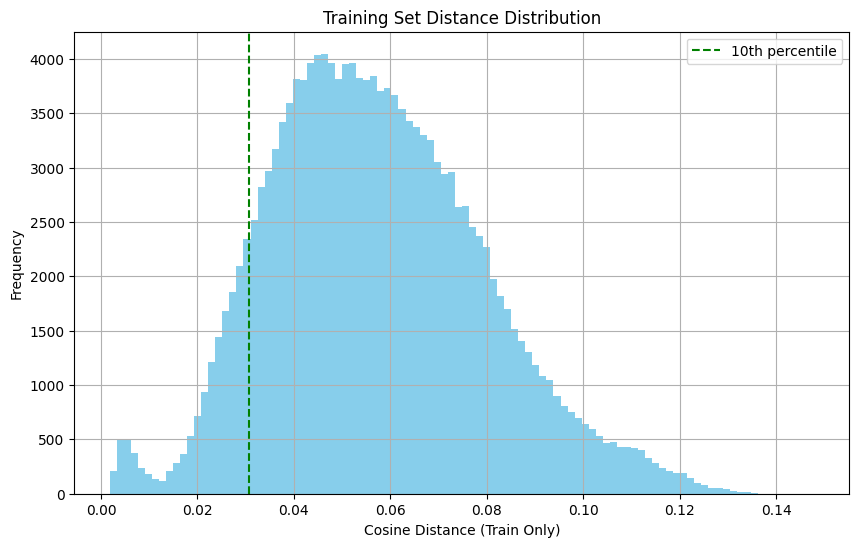

Number of nodes (training only): 554
Number of edges: 15318
Number of connected components: 6


In [ ]:
from sklearn.model_selection import train_test_split
# Step 1: Split off the 15% test set first
X_temp, X_test, y_temp, y_test = train_test_split(
    features, labels, test_size=0.15, stratify=labels, random_state=42
)

# Step 2: Now split the remaining 85% into 70% train and 15% val (so val = 15/85 of remaining)
val_ratio = 15 / 85  # ~0.176
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio, stratify=y_temp, random_state=42
)

# Print shape info
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)
import networkx as nx
from sklearn.metrics.pairwise import pairwise_distances
import matplotlib.pyplot as plt

# Step 1: Compute distance matrix for training set only
train_dist_matrix = pairwise_distances(X_train, metric='cosine')

# Step 2: Flatten the upper triangle to get pairwise distances (excluding self-distances)
train_distances = train_dist_matrix[np.triu_indices_from(train_dist_matrix, k=1)]

# Step 3: Plot histogram to choose epsilon
plt.figure(figsize=(10, 6))
plt.hist(train_distances, bins=100, color='skyblue')
plt.axvline(np.percentile(train_distances, 10), color='green', linestyle='--', label='10th percentile')
plt.xlabel("Cosine Distance (Train Only)")
plt.ylabel("Frequency")
plt.title("Training Set Distance Distribution")
plt.legend()
plt.grid(True)
plt.show()

# Step 4: Choose epsilon (you can tune this percentile)
epsilon = np.percentile(train_distances, 10)

# Step 5: Build epsilon graph **only using training data**
G = nx.Graph()
num_train_samples = X_train.shape[0]
G.add_nodes_from(range(num_train_samples))

# Add edges where distance < epsilon
for i in range(num_train_samples):
    for j in range(i + 1, num_train_samples):
        if train_dist_matrix[i, j] < epsilon:
            G.add_edge(i, j)

# Step 6: Print graph stats
print("Number of nodes (training only):", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Number of connected components:", nx.number_connected_components(G))

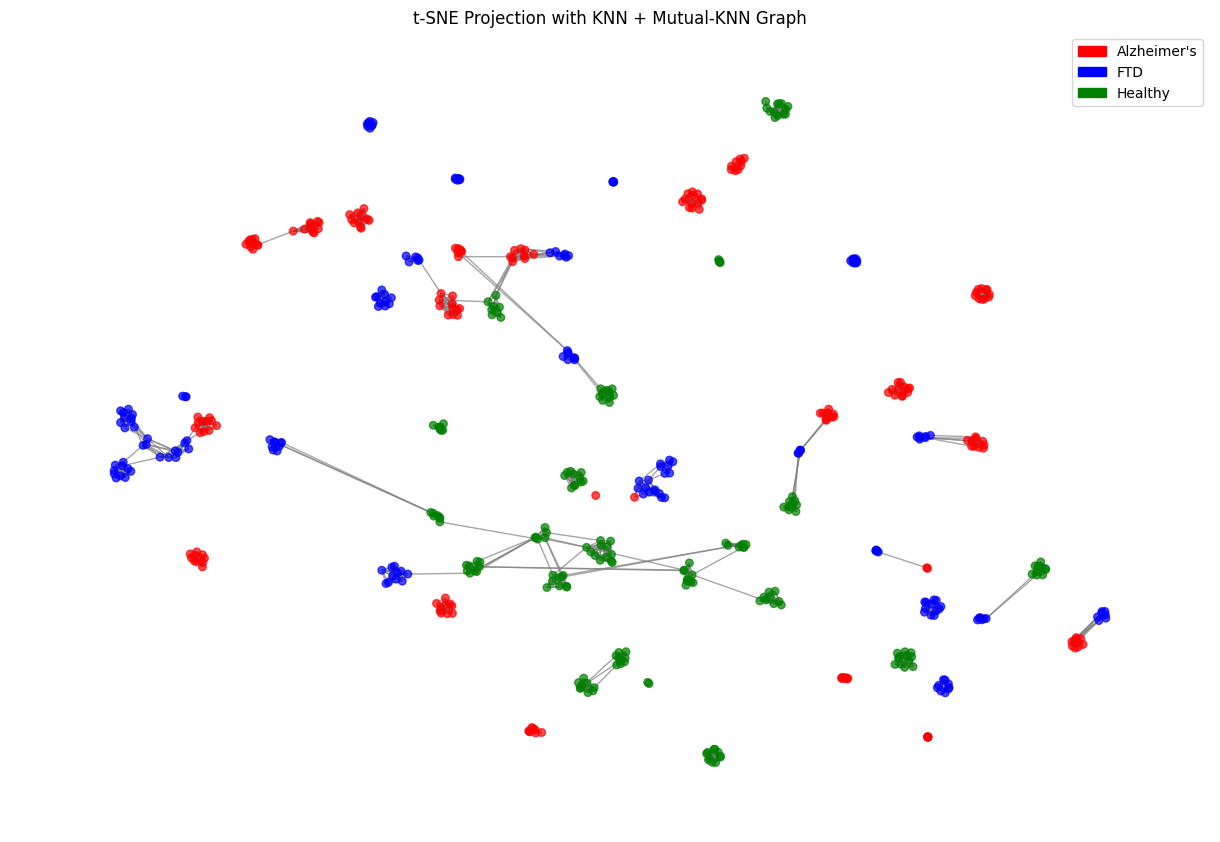

In [ ]:
import numpy as np
import torch
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE

# Parameters
k = 10  # Number of nearest neighbors
random_state = 42

# Step 1: Compute KNN using cosine similarity
nbrs = NearestNeighbors(n_neighbors=k + 1, metric='cosine').fit(X_train)
_, knn_indices = nbrs.kneighbors(X_train)

# Step 2: Mutual-KNN edge construction
mutual_edges = set()
for i, neighbors in enumerate(knn_indices):
    for j in neighbors[1:]:  # Skip self
        if i in knn_indices[j][1:]:  # Mutual condition
            mutual_edges.add((i, j))
            mutual_edges.add((j, i))

# Convert to edge_index format
edge_index = torch.tensor(list(mutual_edges), dtype=torch.long).t().contiguous()

# Step 3: Build graph with NetworkX
G_train = nx.Graph()
G_train.add_nodes_from(range(len(X_train)))
G_train.add_edges_from(edge_index.t().tolist())

# Step 4: t-SNE projection for visualization
tsne = TSNE(n_components=2, metric='cosine', random_state=random_state)
train_2d = tsne.fit_transform(X_train)
pos = {i: tuple(train_2d[i]) for i in range(len(X_train))}

# Step 5: Draw graph
label_color_map = {0: 'red', 1: 'blue', 2: 'green'}
node_colors = [label_color_map[y] for y in y_train]

plt.figure(figsize=(12, 8))
nx.draw(
    G_train, pos,
    node_color=node_colors,
    node_size=30,
    edge_color='gray',
    alpha=0.7,
    with_labels=False
)

# Legend
plt.legend(handles=[
    mpatches.Patch(color='red', label="Alzheimer's"),
    mpatches.Patch(color='blue', label="FTD"),
    mpatches.Patch(color='green', label="Healthy")
], loc='best')

plt.title("t-SNE Projection with KNN + Mutual-KNN Graph")
plt.axis("off")
plt.show()



📂 Fold 1/5
⏹️ Early stopping at epoch 19
✅ Fold 1 Accuracy: 0.8302
[[49  1  3]
 [10 37  6]
 [ 7  0 46]]

📂 Fold 2/5
⏹️ Early stopping at epoch 25
✅ Fold 2 Accuracy: 0.7987
[[40  9  4]
 [ 3 34 16]
 [ 0  0 53]]

📂 Fold 3/5
⏹️ Early stopping at epoch 32
✅ Fold 3 Accuracy: 0.9241
[[42 11  0]
 [ 0 53  0]
 [ 0  1 51]]

📂 Fold 4/5
⏹️ Early stopping at epoch 50
✅ Fold 4 Accuracy: 0.9873
[[52  1  0]
 [ 0 51  1]
 [ 0  0 53]]

📂 Fold 5/5
⏹️ Early stopping at epoch 17
✅ Fold 5 Accuracy: 0.9620
[[46  6  0]
 [ 0 53  0]
 [ 0  0 53]]

🏁 Average Accuracy over 5 folds: 0.9005


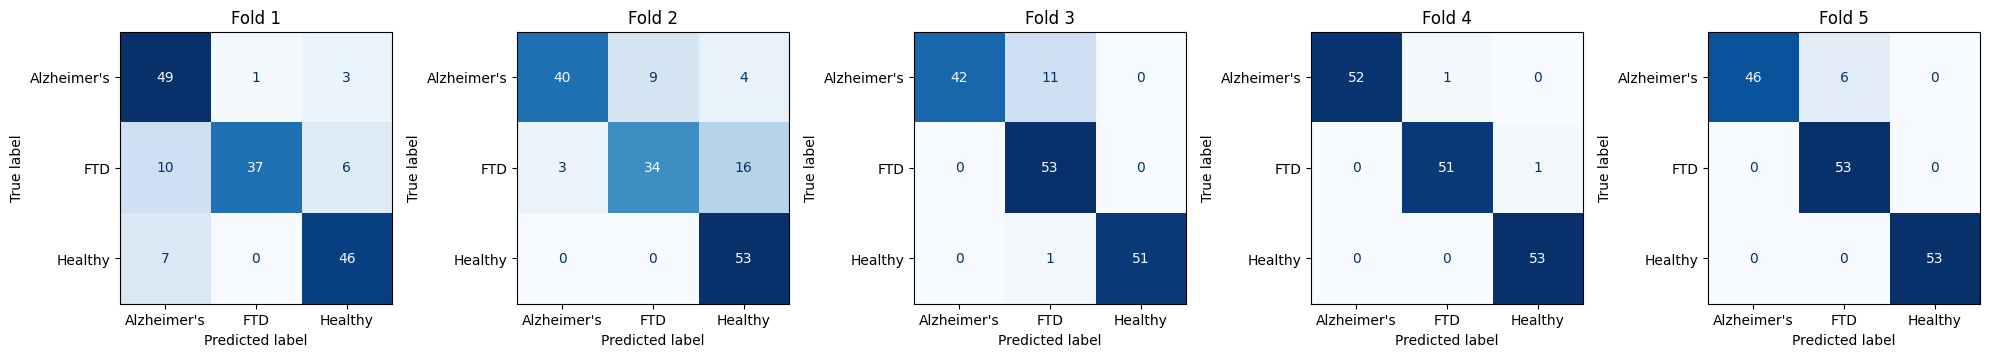

In [ ]:
# --- Imports ---
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from torch_geometric.nn import GATConv
from torch_geometric.data import Data

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Step 1: Normalize Features ---
scaler = StandardScaler()
X = scaler.fit_transform(np.array(all_samples))  # all_samples = list of flattened EEG matrices
y = np.array(labels)

X_tensor = torch.tensor(X, dtype=torch.float)
y_tensor = torch.tensor(y, dtype=torch.long)

# --- Step 2: Build Mutual KNN Graph ---
k = 10
nbrs = NearestNeighbors(n_neighbors=k + 1, metric='cosine').fit(X)
_, knn_indices = nbrs.kneighbors(X)

mutual_edges = set()
for i, neighbors in enumerate(knn_indices):
    for j in neighbors[1:]:
        if i in knn_indices[j][1:]:
            mutual_edges.add((i, j))
            mutual_edges.add((j, i))

edge_index = torch.tensor(list(mutual_edges), dtype=torch.long).t().contiguous()

# --- Step 3: GAT Model ---
class GAT(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, heads=8, feat_dropout=0.2):
        super(GAT, self).__init__()
        self.feat_dropout = feat_dropout
        self.gat1 = GATConv(input_dim, hidden_dim, heads=heads, dropout=0.6)
        self.gat2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, dropout=0.6)
        self.out = nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        if self.training:
            x = F.dropout(x, p=self.feat_dropout)
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.gat2(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        return self.out(x)

# --- Step 4: Class Weights ---
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

# --- Step 5: Cross Validation ---
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
accuracies = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"\n📂 Fold {fold + 1}/{k_folds}")

    train_mask = torch.zeros(X.shape[0], dtype=torch.bool)
    test_mask = torch.zeros(X.shape[0], dtype=torch.bool)
    train_mask[train_idx] = True
    test_mask[test_idx] = True

    data = Data(x=X_tensor, edge_index=edge_index, y=y_tensor,
                train_mask=train_mask, test_mask=test_mask).to(device)

    model = GAT(input_dim=X.shape[1], hidden_dim=64, output_dim=3).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

    best_acc = 0
    best_model = None
    patience, wait = 10, 0

    for epoch in range(1, 201):
        model.train()
        optimizer.zero_grad()
        out = model(data)
        loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        scheduler.step()

        # Validation
        model.eval()
        with torch.no_grad():
            logits = model(data)
            preds = logits.argmax(dim=1)
            pred_test = preds[data.test_mask].cpu().numpy()
            true_test = data.y[data.test_mask].cpu().numpy()
            acc = accuracy_score(true_test, pred_test)

            if acc > best_acc:
                best_acc = acc
                best_model = model.state_dict()
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    print(f"⏹️ Early stopping at epoch {epoch}")
                    break

    # Load best model
    model.load_state_dict(best_model)
    model.eval()
    with torch.no_grad():
        logits = model(data)
        preds = logits.argmax(dim=1)
        true = data.y
        pred_test = preds[data.test_mask].cpu().numpy()
        true_test = true[data.test_mask].cpu().numpy()

        acc = accuracy_score(true_test, pred_test)
        cm = confusion_matrix(true_test, pred_test)
        accuracies.append(acc)
        conf_matrices.append(cm)

        print(f"✅ Fold {fold + 1} Accuracy: {acc:.4f}")
        print(cm)

# --- Step 6: Summary ---
print(f"\n🏁 Average Accuracy over {k_folds} folds: {np.mean(accuracies):.4f}")

# --- Step 7: Plot Confusion Matrices ---
fig, axes = plt.subplots(1, k_folds, figsize=(20, 4))
class_names = ["Alzheimer's", "FTD", "Healthy"]

for i, cm in enumerate(conf_matrices):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[i], cmap=plt.cm.Blues, values_format='d', colorbar=False)
    axes[i].set_title(f"Fold {i+1}")
    axes[i].grid(False)

plt.tight_layout()
plt.show()



🚀 Training with 10% of training data in each fold
📂 Fold 1 Accuracy: 0.3333
📂 Fold 2 Accuracy: 0.3333
📂 Fold 3 Accuracy: 0.3544
📂 Fold 4 Accuracy: 0.3354
📂 Fold 5 Accuracy: 0.3291
✅ Best Fold Accuracy with 10% training: 0.3544

🚀 Training with 20% of training data in each fold
📂 Fold 1 Accuracy: 0.3333
📂 Fold 2 Accuracy: 0.3333
📂 Fold 3 Accuracy: 0.3354
📂 Fold 4 Accuracy: 0.3354
📂 Fold 5 Accuracy: 0.3291
✅ Best Fold Accuracy with 20% training: 0.3354

🚀 Training with 30% of training data in each fold
📂 Fold 1 Accuracy: 0.3333
📂 Fold 2 Accuracy: 0.3333
📂 Fold 3 Accuracy: 0.3354
📂 Fold 4 Accuracy: 0.3354
📂 Fold 5 Accuracy: 0.3291
✅ Best Fold Accuracy with 30% training: 0.3354

🚀 Training with 40% of training data in each fold
📂 Fold 1 Accuracy: 0.3836
📂 Fold 2 Accuracy: 0.4591
📂 Fold 3 Accuracy: 0.4304
📂 Fold 4 Accuracy: 0.4051
📂 Fold 5 Accuracy: 0.4304
✅ Best Fold Accuracy with 40% training: 0.4591

🚀 Training with 50% of training data in each fold
📂 Fold 1 Accuracy: 0.4654
📂 Fold 2 Ac

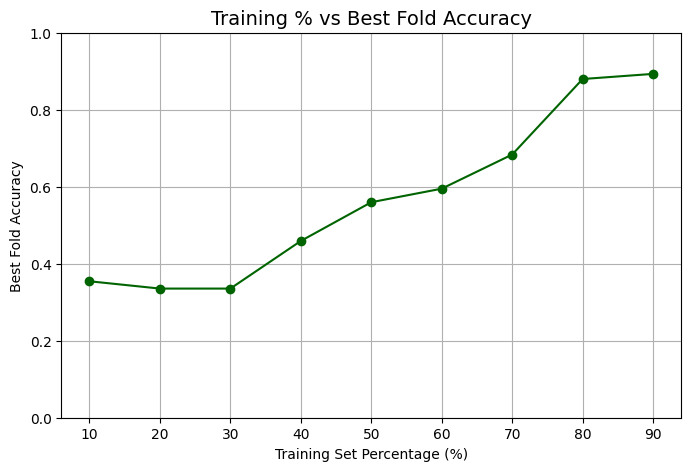

In [ ]:
# --- Train Size Sweep: 10% to 90% ---
train_sizes = [i / 100 for i in range(10, 100, 10)]  # [0.1, 0.2, ..., 0.9]
best_fold_accuracies = []

for train_ratio in train_sizes:
    print(f"\n🚀 Training with {int(train_ratio * 100)}% of training data in each fold")

    k_folds = 5
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    fold_accuracies = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        # Reduce the training set to given percentage
        num_train = int(len(train_idx) * train_ratio)
        reduced_train_idx = train_idx[:num_train]

        train_mask = torch.zeros(X.shape[0], dtype=torch.bool)
        test_mask = torch.zeros(X.shape[0], dtype=torch.bool)
        train_mask[reduced_train_idx] = True
        test_mask[test_idx] = True

        data = Data(x=X_tensor, edge_index=edge_index, y=y_tensor,
                    train_mask=train_mask, test_mask=test_mask).to(device)

        model = GAT(input_dim=X.shape[1], hidden_dim=64, output_dim=3).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

        best_acc = 0
        best_model = None
        patience, wait = 10, 0

        for epoch in range(1, 201):
            model.train()
            optimizer.zero_grad()
            out = model(data)
            loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer.step()
            scheduler.step()

            # Validation (test)
            model.eval()
            with torch.no_grad():
                logits = model(data)
                preds = logits.argmax(dim=1)
                pred_test = preds[data.test_mask].cpu().numpy()
                true_test = data.y[data.test_mask].cpu().numpy()
                acc = accuracy_score(true_test, pred_test)

                if acc > best_acc:
                    best_acc = acc
                    best_model = model.state_dict()
                    wait = 0
                else:
                    wait += 1
                    if wait >= patience:
                        break

        # Load and evaluate best model
        model.load_state_dict(best_model)
        model.eval()
        with torch.no_grad():
            logits = model(data)
            preds = logits.argmax(dim=1)
            pred_test = preds[data.test_mask].cpu().numpy()
            true_test = data.y[data.test_mask].cpu().numpy()
            acc = accuracy_score(true_test, pred_test)
            fold_accuracies.append(acc)

        print(f"📂 Fold {fold + 1} Accuracy: {acc:.4f}")

    # Take best accuracy among the 5 folds
    max_fold_acc = max(fold_accuracies)
    best_fold_accuracies.append(max_fold_acc)
    print(f"✅ Best Fold Accuracy with {int(train_ratio * 100)}% training: {max_fold_acc:.4f}")

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.plot([int(r * 100) for r in train_sizes], best_fold_accuracies, marker='o', linestyle='-', color='darkgreen')
plt.title("Training % vs Best Fold Accuracy", fontsize=14)
plt.xlabel("Training Set Percentage (%)")
plt.ylabel("Best Fold Accuracy")
plt.grid(True)
plt.ylim(0, 1)
plt.xticks(range(10, 100, 10))
plt.show()
